# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">MatrixBrekzie 50°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 456
Average Fx in the averaging interval [1078:1534]: 4.859121383073037
Average Fz in the averaging interval [1078:1534]: 1.5022860610694218
Maximum Fz in the plotting interval [1078:None]: 2.83651123046875 at timestep 1465
Time step where Fx drops below 1: 1534


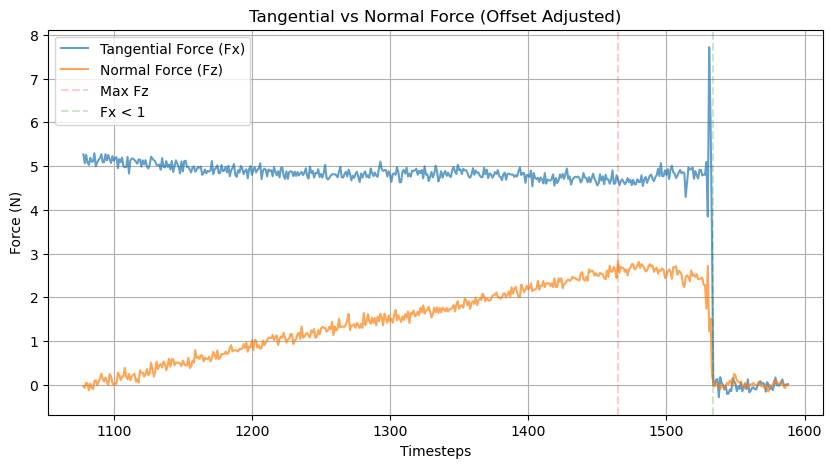

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232030.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1078, cut_2=None, avg_end=1534, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 489
Average Fx in the averaging interval [743:1232]: 4.554893083708906
Average Fz in the averaging interval [743:1232]: 1.5515332680294605
Maximum Fz in the plotting interval [743:None]: 2.9880574544270835 at timestep 1219
Time step where Fx drops below 1: 1232


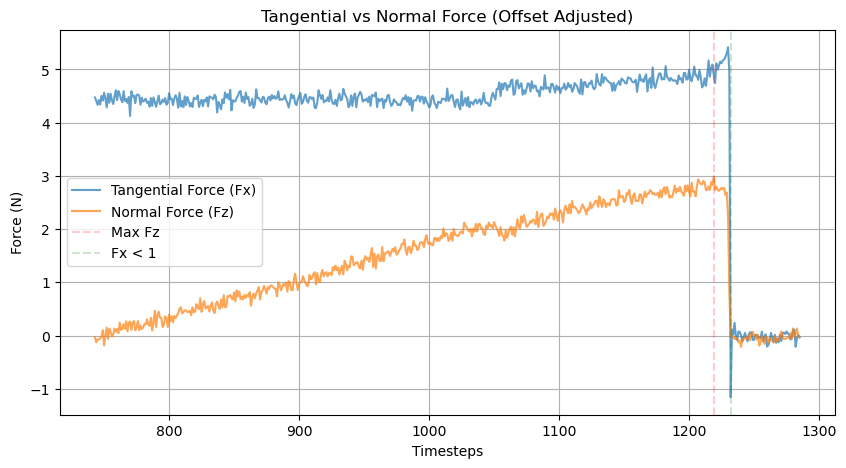

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232031.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=743, cut_2=None, avg_end=1232, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 169
Average Fx in the averaging interval [870:1039]: 4.526915395988751
Average Fz in the averaging interval [870:1039]: 0.38861883340267506
Maximum Fz in the plotting interval [870:None]: 0.9122639973958333 at timestep 1014
Time step where Fx drops below 1: 1039


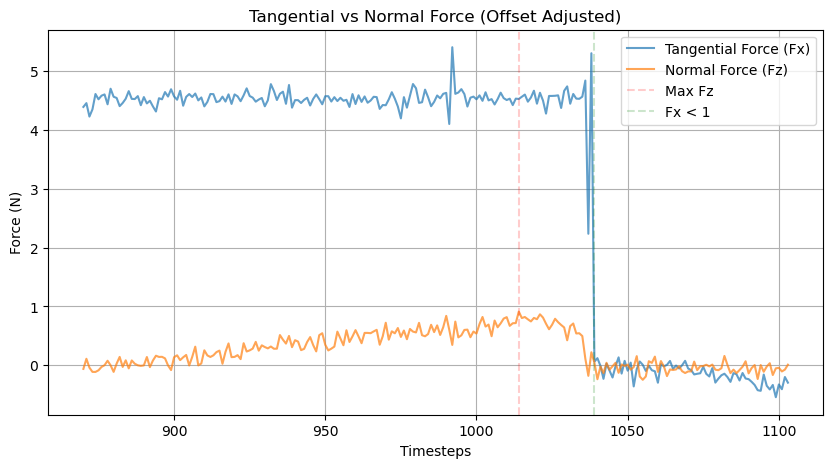

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232033.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=870, cut_2=None, avg_end=1039, offset_position='beginning', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 1379
Average Fx in the averaging interval [650:2029]: 4.7553141735704845
Average Fz in the averaging interval [650:2029]: 2.7115604716912545
Maximum Fz in the plotting interval [650:None]: 5.640372721354167 at timestep 2010
Time step where Fx drops below 1: 2029


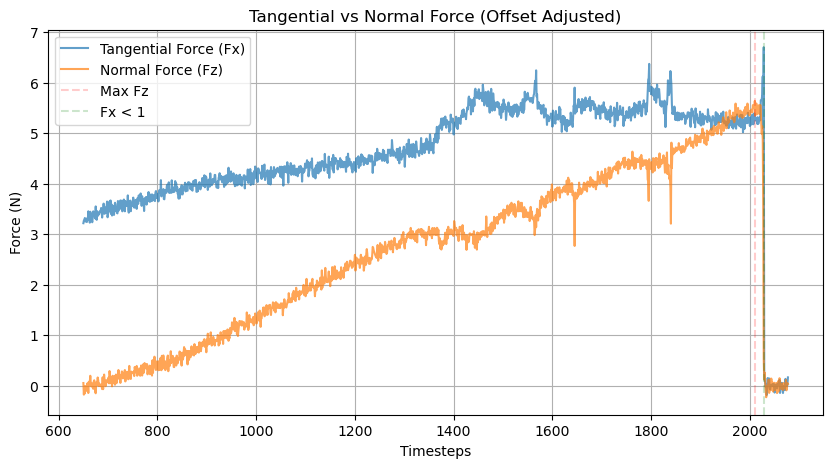

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232034.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=650, cut_2=None, avg_end=2029, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 610
Average Fx in the averaging interval [829:1439]: 4.823420032126005
Average Fz in the averaging interval [829:1439]: 1.5375356538699625
Maximum Fz in the plotting interval [829:None]: 2.949812825520833 at timestep 1391
Time step where Fx drops below 1: 1439


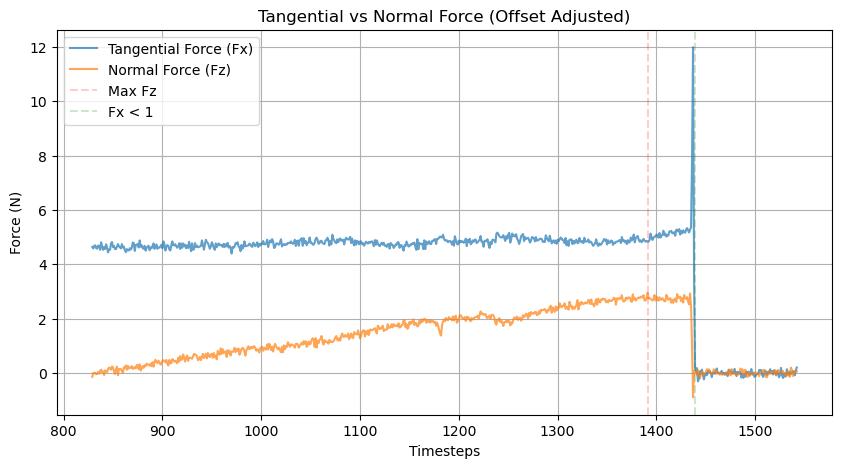

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232035.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=829, cut_2=None, avg_end=1439, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 380
Average Fx in the averaging interval [780:1160]: 4.786342200061731
Average Fz in the averaging interval [780:1160]: 1.357028947796738
Maximum Fz in the plotting interval [780:None]: 2.5649373372395834 at timestep 1151
Time step where Fx drops below 1: 1160


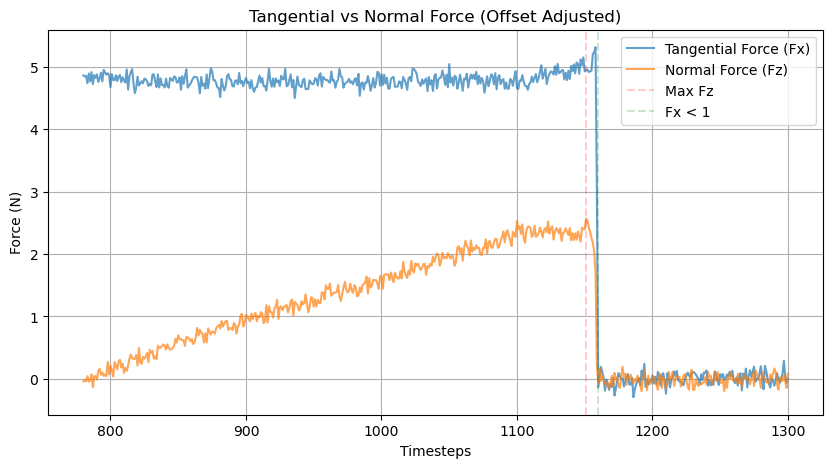

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232037.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=780, cut_2=None, avg_end=1160, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 501
Average Fx in the averaging interval [730:1231]: 4.559938923422686
Average Fz in the averaging interval [730:1231]: 1.5377685303221682
Maximum Fz in the plotting interval [730:None]: 3.102067057291667 at timestep 1209
Time step where Fx drops below 1: 1231


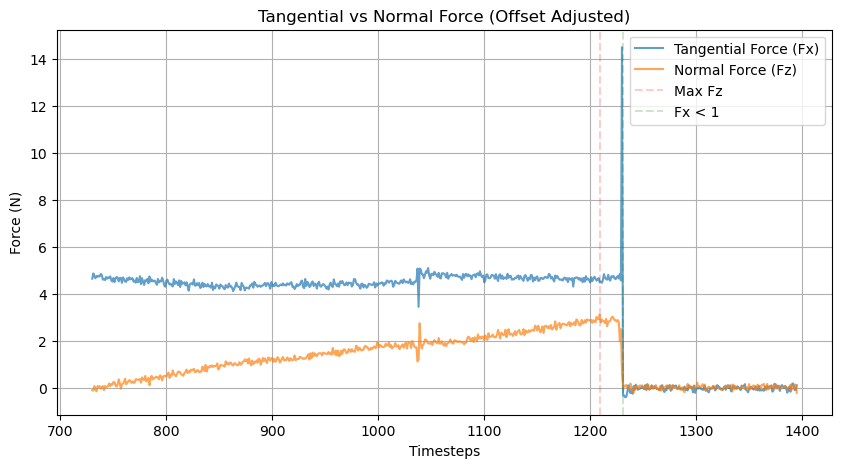

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232038.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=730, cut_2=None, avg_end=1231, offset_position='end', offset_length=15)

<font size="6">Test 8: (prematurely ended!)</font>

Average Fx in the averaging interval [None:None]: 3.3877950448256273
Average Fz in the averaging interval [None:None]: -1.5461333446013623
Maximum Fz in the plotting interval [None:None]: 0.1850341796875 at timestep 22
Time step where Fx drops below 1: 0


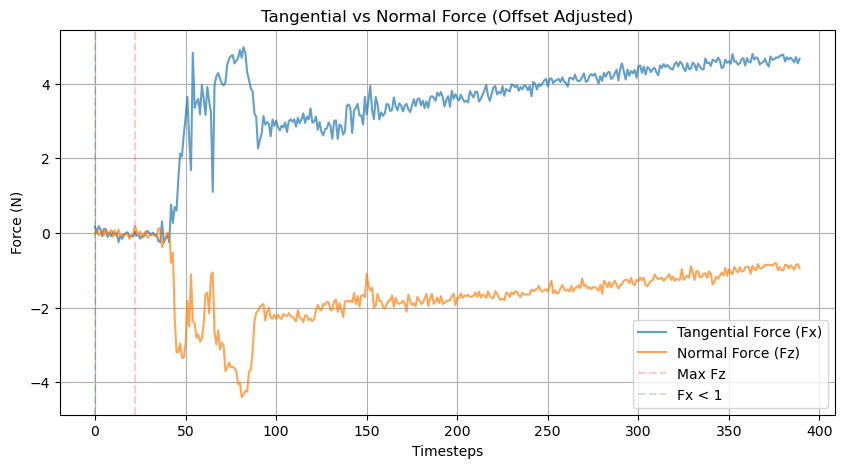

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232040.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 339
Average Fx in the averaging interval [645:984]: 4.357872145998795
Average Fz in the averaging interval [645:984]: 0.44239883647907446
Maximum Fz in the plotting interval [645:None]: 1.1199544270833333 at timestep 823
Time step where Fx drops below 1: 985


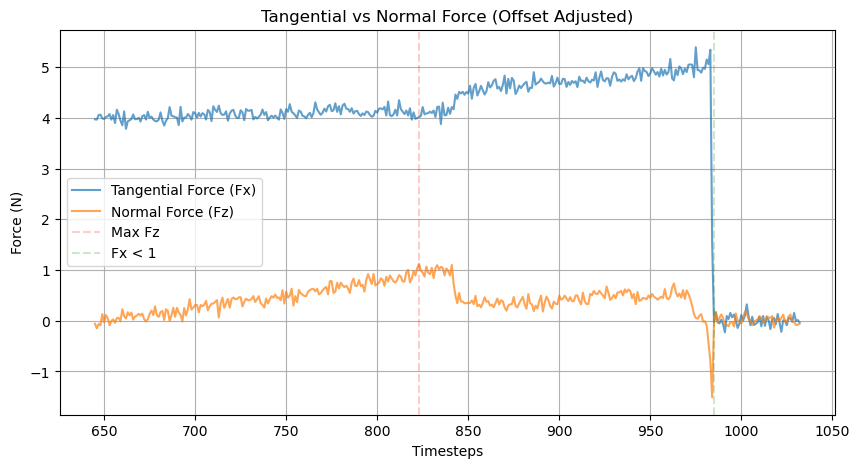

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232041.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=645, cut_2=None, avg_end=984, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 1440
Average Fx in the averaging interval [785:2225]: 5.943082584606277
Average Fz in the averaging interval [785:2225]: 3.471222093370226
Maximum Fz in the plotting interval [785:None]: 6.792472330729167 at timestep 2198
Time step where Fx drops below 1: 2225


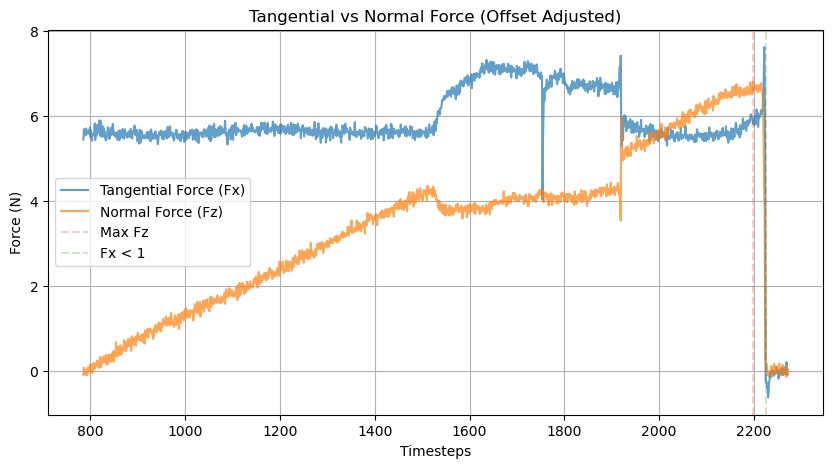

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_50_5N//log_202405232042.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=785, cut_2=None, avg_end=2225, offset_position='end', offset_length=15)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//50//MatrixBrekzie_50_stats.csv", index=False)

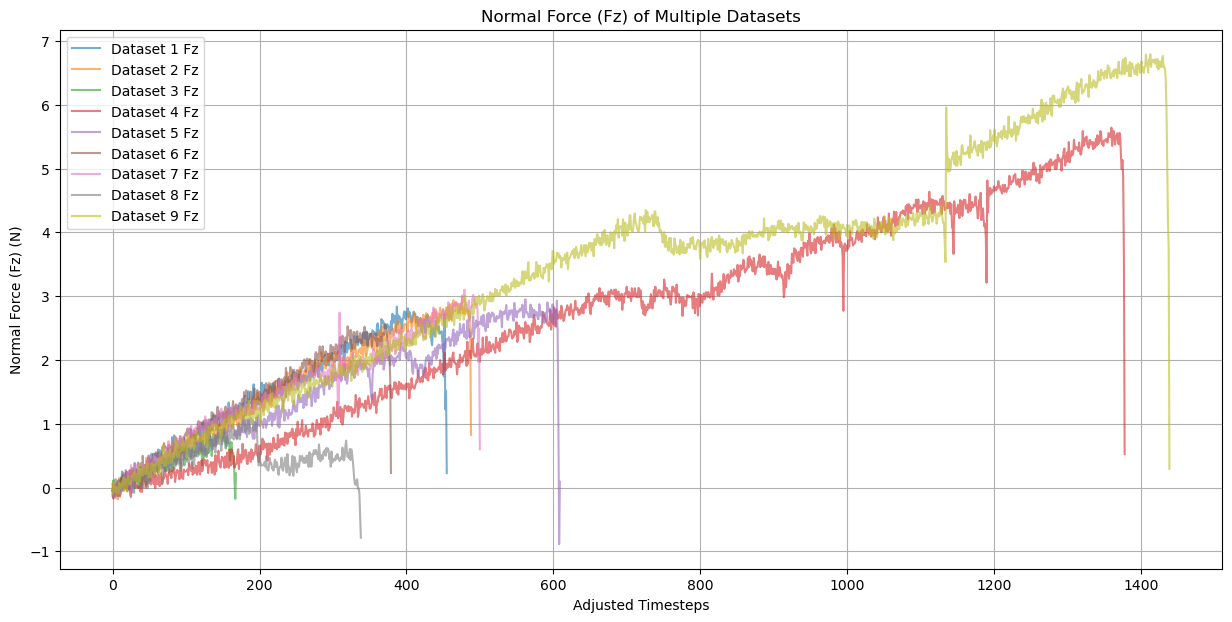

Average of maximum Fz forces: 3.2118277090567133
Standard deviation of maximum Fz forces: 1.7973089703549379
Average of average Fz forces: 1.6111058551145534
Standard deviation of average Fz forces: 0.920272909394473
Average of average Fx forces: 4.796322213617407
Standard deviation of average Fx forces: 0.4346776859253886


In [18]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//50//MatrixBrekzie_50"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)